# Fine-tuning Submission PGABL - Dedy Irama

Notebook fine-tuning LLM dengan Unsloth, QLoRA, validasi, dua eksperimen, dan push model ke Hugging Face.

## 0. Cek GPU

In [1]:
!nvidia-smi

Fri Jun 26 12:54:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Instalasi Library

In [2]:
%%capture
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps trl peft accelerate bitsandbytes xformers
!pip install -q datasets transformers huggingface_hub sentence-transformers pypdf gdown
!pip install -q langchain langchain-community langchain-huggingface faiss-cpu rank-bm25 gradio matplotlib pandas

## 2. Konfigurasi dan Login Hugging Face

Token dibaca dari Colab Secrets `HF_TOKEN`.

In [3]:
import os
from pathlib import Path
from getpass import getpass

HF_REPO_ID = "dedyirama/dicoding-llm"
DATASET_ID = "Ichsan2895/alpaca-gpt4-indonesian"
BASE_MODEL = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"

PROJECT_DIR = Path("/content")
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("HF_REPO_ID:", HF_REPO_ID)

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.getenv("HF_TOKEN")

if not HF_TOKEN:
    HF_TOKEN = getpass("Masukkan Hugging Face write token: ")

from huggingface_hub import login
login(token=HF_TOKEN)

(PROJECT_DIR / "link_huggingface.txt").write_text(f"https://huggingface.co/{HF_REPO_ID}\n", encoding="utf-8")

PROJECT_DIR: /content
HF_REPO_ID: dedyirama/dicoding-llm


46

## 3. Load Model dengan QLoRA 4-bit dan Double Quantization

Model memakai keluarga Qwen yang didukung Unsloth dan dirancang untuk text generation. LoRA adapter dipasang pada komponen attention dan feed-forward network.

In [4]:
import torch
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from unsloth import is_bfloat16_supported

MAX_SEQ_LENGTH = 2048
DTYPE = None

def load_qlora_model(lora_r=16, lora_alpha=16, lora_dropout=0.0):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=DTYPE,
        load_in_4bit=True,
        token=HF_TOKEN,
    )
    tokenizer = get_chat_template(tokenizer, chat_template='chatml')
    model = FastLanguageModel.get_peft_model(
        model,
        r=lora_r,
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias='none',
        use_gradient_checkpointing='unsloth',
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
    return model, tokenizer

model, tokenizer = load_qlora_model(lora_r=16, lora_alpha=16)
print('Model loaded:', BASE_MODEL)
print('Quantization config:', getattr(model.config, 'quantization_config', None))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Will map <|im_end|> to EOS = <|im_end|>.
Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded: unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
Quantization config: {'bnb_4bit_compute_dtype': torch.float16, 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': None, 'llm_int8_threshold': 6.0, 'load_in_4bit': True, 'load_in_8bit': False, 'quant_method': 'bitsandbytes'}


## 4. Load Dataset dan Mapping ke Chat Template

Dataset dipetakan menggunakan `datasets.map()` menjadi teks chat template ChatML. Dataset memakai kolom `input` sebagai prompt user dan `output` sebagai jawaban assistant.

In [5]:
from datasets import load_dataset

raw_dataset = load_dataset(DATASET_ID, split='train')
print(raw_dataset)
print(raw_dataset.column_names)
print('Contoh data mentah:')
print(raw_dataset[0])

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

alpaca-gpt4-indonesia.csv:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49969 [00:00<?, ? examples/s]

Dataset({
    features: ['Unnamed: 0', 'input', 'output'],
    num_rows: 49969
})
['Unnamed: 0', 'input', 'output']
Contoh data mentah:
{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


In [6]:
columns = set(raw_dataset.column_names)
if 'output' not in columns:
    raise ValueError(f"Dataset harus memiliki kolom 'output'. Kolom tersedia: {raw_dataset.column_names}")
if 'instruction' not in columns and 'input' not in columns:
    raise ValueError(f"Dataset harus memiliki kolom 'instruction' atau 'input'. Kolom tersedia: {raw_dataset.column_names}")

HAS_INSTRUCTION_COLUMN = 'instruction' in columns
HAS_INPUT_COLUMN = 'input' in columns
print('HAS_INSTRUCTION_COLUMN:', HAS_INSTRUCTION_COLUMN)
print('HAS_INPUT_COLUMN:', HAS_INPUT_COLUMN)

split_dataset = raw_dataset.train_test_split(test_size=0.05, seed=3407)

def alpaca_to_chat_template(batch):
    texts = []
    batch_size = len(batch['output'])
    for idx in range(batch_size):
        output_text = batch['output'][idx] or ''
        if HAS_INSTRUCTION_COLUMN:
            instruction = batch['instruction'][idx] or ''
            input_text = batch['input'][idx] if HAS_INPUT_COLUMN else ''
            input_text = input_text or ''
            user_content = instruction.strip()
            if input_text.strip():
                user_content = f"{user_content}\n\nInput:\n{input_text.strip()}"
        else:
            user_content = (batch['input'][idx] or '').strip()
        messages = [
            {'role': 'user', 'content': user_content},
            {'role': 'assistant', 'content': output_text.strip()},
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        texts.append(text)
    return {'text': texts}

mapped_dataset = split_dataset.map(
    alpaca_to_chat_template,
    batched=True,
    remove_columns=raw_dataset.column_names,
    desc='Mapping Alpaca ke ChatML',
)

print(mapped_dataset)
print('\nContoh data SETELAH mapping ke chat template:')
print(mapped_dataset['train'][0]['text'])

HAS_INSTRUCTION_COLUMN: False
HAS_INPUT_COLUMN: True


Mapping Alpaca ke ChatML:   0%|          | 0/47470 [00:00<?, ? examples/s]

Mapping Alpaca ke ChatML:   0%|          | 0/2499 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 47470
    })
    test: Dataset({
        features: ['text'],
        num_rows: 2499
    })
})

Contoh data SETELAH mapping ke chat template:
<|im_start|>user
Deskripsikan kemajuan teknologi terbaru yang menurutmu sangat menarik.<|im_end|>
<|im_start|>assistant
Salah satu kemajuan teknologi terbaru yang saya temukan sangat menarik adalah pengembangan antarmuka otak-komputer (BCI). BCI adalah teknologi yang memungkinkan komunikasi langsung antara otak manusia dan perangkat eksternal, memungkinkan individu untuk mengontrol komputer dan teknologi lainnya hanya dengan pikiran mereka. Inovasi ini memiliki potensi untuk merevolusi cara kita berinteraksi dengan teknologi dan memiliki banyak aplikasi, terutama di bidang kedokteran. Misalnya, teknologi BCI dapat digunakan untuk membantu individu yang kehilangan kemampuan bergerak atau berkomunikasi karena kelumpuhan atau kondisi lain untuk mendapatkan kembali kendal

## 5. Fine-tuning dengan SFTTrainer: 2 Eksperimen

Dua eksperimen dijalankan minimal 800 steps. Setelah selesai, dipilih eksperimen dengan validation loss terbaik untuk di-push ke Hugging Face.

In [7]:
import inspect
import pandas as pd
import matplotlib.pyplot as plt
from trl import SFTTrainer
from transformers import TrainingArguments

EXPERIMENTS = [
    {
        'name': 'exp1_r16_lr2e-4',
        'lora_r': 16,
        'lora_alpha': 16,
        'learning_rate': 2e-4,
        'per_device_train_batch_size': 2,
        'gradient_accumulation_steps': 4,
        'max_steps': 800,
    },
    {
        'name': 'exp2_r32_lr1e-4',
        'lora_r': 32,
        'lora_alpha': 32,
        'learning_rate': 1e-4,
        'per_device_train_batch_size': 2,
        'gradient_accumulation_steps': 4,
        'max_steps': 800,
    },
]

def build_training_args(exp):
    eval_arg_name = 'eval_strategy' if 'eval_strategy' in inspect.signature(TrainingArguments.__init__).parameters else 'evaluation_strategy'
    kwargs = dict(
        output_dir=str(OUTPUT_DIR / exp['name']),
        per_device_train_batch_size=exp['per_device_train_batch_size'],
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=exp['gradient_accumulation_steps'],
        warmup_steps=50,
        max_steps=exp['max_steps'],
        learning_rate=exp['learning_rate'],
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=25,
        eval_steps=100,
        save_strategy='no',
        optim='adamw_8bit',
        weight_decay=0.01,
        lr_scheduler_type='linear',
        seed=3407,
        report_to='none',
    )
    kwargs[eval_arg_name] = 'steps'
    return TrainingArguments(**kwargs)

def run_experiment(exp):
    print(f"\n===== Running {exp['name']} =====")
    exp_model, exp_tokenizer = load_qlora_model(lora_r=exp['lora_r'], lora_alpha=exp['lora_alpha'])
    trainer = SFTTrainer(
        model=exp_model,
        tokenizer=exp_tokenizer,
        train_dataset=mapped_dataset['train'],
        eval_dataset=mapped_dataset['test'],
        dataset_text_field='text',
        max_seq_length=MAX_SEQ_LENGTH,
        packing=False,
        args=build_training_args(exp),
    )
    train_result = trainer.train()
    eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]
    metrics = eval_logs[-1] if eval_logs else train_result.metrics
    adapter_dir = OUTPUT_DIR / exp['name'] / 'adapter'
    trainer.model.save_pretrained(adapter_dir)
    exp_tokenizer.save_pretrained(adapter_dir)
    logs = pd.DataFrame(trainer.state.log_history)
    logs.to_csv(OUTPUT_DIR / exp['name'] / 'trainer_logs.csv', index=False)
    result = {
        'name': exp['name'],
        'metrics': metrics,
        'adapter_dir': str(adapter_dir),
        'logs': logs,
    }
    del trainer, exp_model
    torch.cuda.empty_cache()
    return result

experiment_results = []
for exp in EXPERIMENTS:
    experiment_results.append(run_experiment(exp))
    torch.cuda.empty_cache()

summary_rows = []
for result in experiment_results:
    summary_rows.append({'name': result['name'], **result['metrics']})
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / 'experiment_summary.csv', index=False)

best_result = min(experiment_results, key=lambda item: item['metrics'].get('eval_loss', float('inf')))
print('Best experiment:', best_result['name'])


===== Running exp1_r16_lr2e-4 =====
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/47470 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/2499 [00:00<?, ? examples/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 36,929,536 of 1,580,643,840 (2.34% trained)


Step,Training Loss,Validation Loss
100,1.440141,1.468120
200,1.394421,1.437722
300,1.345838,1.417702
400,1.419202,1.404198
500,1.360405,1.392060
600,1.349934,1.386548
700,1.353196,1.380989
800,1.337256,1.378427


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Unsloth: Restored added_tokens_decoder metadata in /content/outputs/exp2_r32_lr1e-4/adapter/tokenizer_config.json.


,name,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,exp1_r16_lr2e-4,1.372560,425.8063,5.869,5.869,0.134822,800
1,exp2_r32_lr1e-4,1.378427,428.2583,5.835,5.835,0.134822,800


Best experiment: exp1_r16_lr2e-4


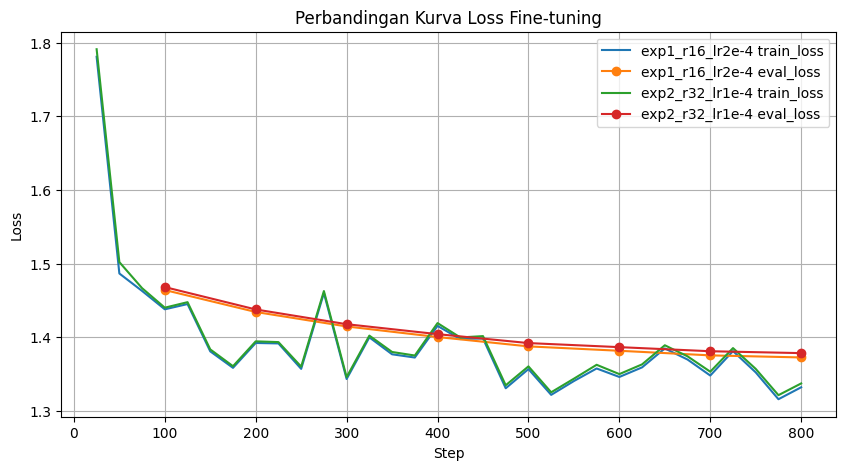

In [8]:
plt.figure(figsize=(10, 5))
for result in experiment_results:
    logs = result['logs']
    train_logs = logs.dropna(subset=['loss']) if 'loss' in logs.columns else pd.DataFrame()
    eval_logs = logs.dropna(subset=['eval_loss']) if 'eval_loss' in logs.columns else pd.DataFrame()
    if not train_logs.empty:
        plt.plot(train_logs['step'], train_logs['loss'], label=f"{result['name']} train_loss")
    if not eval_logs.empty:
        plt.plot(eval_logs['step'], eval_logs['eval_loss'], marker='o', label=f"{result['name']} eval_loss")
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Perbandingan Kurva Loss Fine-tuning')
plt.legend()
plt.grid(True)
plt.show()

## 6. Push Model Fine-tuned ke Hugging Face

Model terbaik dipush dengan metode `merged_16bit` agar dapat dipanggil kembali pada tahap RAG.

In [ ]:
best_adapter_dir = best_result['adapter_dir']
print('Loading best adapter from:', best_adapter_dir)

best_model, best_tokenizer = FastLanguageModel.from_pretrained(
    model_name=best_adapter_dir,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=True,
    token=HF_TOKEN,
)

local_merged_dir = OUTPUT_DIR / 'model_merged_16bit'
best_model.save_pretrained_merged(str(local_merged_dir), best_tokenizer, save_method='merged_16bit')
best_model.push_to_hub_merged(HF_REPO_ID, best_tokenizer, save_method='merged_16bit', token=HF_TOKEN)

(PROJECT_DIR / 'link_huggingface.txt').write_text(f'https://huggingface.co/{HF_REPO_ID}\n', encoding='utf-8')
print('Model pushed to:', f'https://huggingface.co/{HF_REPO_ID}')

Loading best adapter from: /content/outputs/exp1_r16_lr2e-4/adapter
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/outputs/model_merged_16bit/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:37<00:00, 37.33s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit:   0%|          | 0/1 [00:00<?, ?it/s]